## Notebook 1: Importing Data & EDA - Phase 1

**Benchmark Paper:** Krauss, C., Do, X. A., & Huck, N. (2017). Deep neural networks, gradient-boosted trees, random forests: Statistical arbitrage on the S&P 500. *European Journal of Operational Research*, 259(2), 689–702.

### Objective
The objectives for this NB are:
1. Download daily OHLCV data for SPY aka S&P 500 ETF using `yfinance` library (yahoo)
2. Verifying and Understanding the market data - interpretations as md along the way
3. Stationarity testing (ADF Test) - required before feeding data to ML models
4. Dynamic Time Warping (DTW) - used instead of Pearson correlation for time-series similarity
5. Train the RF model

## 1. Install & Import Dependencies

In [1]:
%pip install yfinance dtaidistance

import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
from pathlib import Path

# Data download
import yfinance as yf

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Statistical tests
from statsmodels.tsa.stattools import adfuller
from scipy import stats

# Dynamic Time Warping
from dtaidistance import dtw

# Settings
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('All dependencies loaded successfully.')

Note: you may need to restart the kernel to use updated packages.
All dependencies loaded successfully.


## 2. Data Download

Using yahoo finance and downloading:
- **SPY** aka S&P 500 ETF 
- **^VIX** aka Volatility Index 

Period: **2015-01-01 to 2023-12-31** 
Justification: The benchmark paper used 1992–2015. We extend it to see if profitable trading patterns still exist in more recent, AI-aware markets.

In [2]:
# Configuration 
TICKER   = 'SPY'
START    = '2015-01-01'
END      = '2023-12-31'
RISK_FREE_RATE = 0.02  # Annualised risk-free rate for Sharpe calculation (approx US T-bill avg)

# Output folders
FIG_DIR = Path('figures/EDA')
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path('data')
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Download primary instrument
print(f'Downloading {TICKER} ({START} to {END})...')
raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
raw.index = pd.to_datetime(raw.index)

# Download VIX for regime context
print('Downloading ^VIX...')
vix = yf.download('^VIX', start=START, end=END, auto_adjust=True, progress=False)[['Close']]
vix.columns = ['VIX']
vix.index = pd.to_datetime(vix.index)

print(f'\n{TICKER} — {len(raw)} trading days downloaded.')
print(f'Date range: {raw.index[0].date()} → {raw.index[-1].date()}')
print(f'\nColumns: {list(raw.columns)}')
print(f'Figures will be saved to: {FIG_DIR.resolve()}')
print(f'Data will be saved to: {DATA_DIR.resolve()}')
raw.head()


SPY — 2264 trading days downloaded.
Date range: 2015-01-02 → 2023-12-29

Columns: [('Close', 'SPY'), ('High', 'SPY'), ('Low', 'SPY'), ('Open', 'SPY'), ('Volume', 'SPY')]
Figures will be saved to: G:\My Drive\Masters\SEM2\Algo Trading\ARI5123 - Algo. Trading Project\figures\EDA
Data will be saved to: G:\My Drive\Masters\SEM2\Algo Trading\ARI5123 - Algo. Trading Project\data


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2015-01-02,170.1250,171.3258,169.0898,170.9118,121465900
2015-01-05,167.0526,169.2472,166.7462,169.0816,169632600
2015-01-06,165.4791,167.8807,164.6841,167.3590,209151400
2015-01-07,167.5412,167.8807,166.3570,166.8042,125346700
2015-01-08,170.5142,170.7295,168.9325,168.9490,147217800


In [3]:
# Data quality check
print('=== Missing Values ===')
print(raw.isnull().sum())

print('\n=== Duplicate Indices ===')
print(f'Duplicate dates: {raw.index.duplicated().sum()}')

print('\n=== Basic Statistics ===')
print(raw.describe())

=== Missing Values ===
Price   Ticker
Close   SPY       0
High    SPY       0
Low     SPY       0
Open    SPY       0
Volume  SPY       0
dtype: int64

=== Duplicate Indices ===
Duplicate dates: 0

=== Basic Statistics ===
Price      Close      High       Low      Open         Volume
Ticker       SPY       SPY       SPY       SPY            SPY
count  2264.0000 2264.0000 2264.0000 2264.0000      2264.0000
mean    284.9487  286.5102  283.1615  284.8991  90777901.9876
std      91.2366   91.8167   90.5779   91.2098  45618826.1503
min     154.5588  155.6069  152.4652  154.1193  20270000.0000
25%     204.4973  205.1541  203.8852  204.7219  61893275.0000
50%     260.0476  261.1890  258.5806  259.8687  78881700.0000
75%     378.1760  380.9929  375.1959  378.0520 105053700.0000
max     463.9230  464.7599  463.5045  464.1079 507244300.0000


In [4]:
# Compute derived columns used throughout the project
df = raw.copy()

# Flatten MultiIndex columns if present (yfinance ≥ 0.2 returns MultiIndex for single tickers)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] for col in df.columns]

# Daily log return — preferred over simple return for ML (additive, approx normal)
df['log_return']    = np.log(df['Close'] / df['Close'].shift(1))

# Simple return (used for P&L and Sharpe calculations)
df['simple_return'] = df['Close'].pct_change()

# Rolling volatility (20-day)
df['vol_20d']       = df['log_return'].rolling(20).std() * np.sqrt(252)

# Merge VIX
df = df.join(vix, how='left')

# Drop first row (NaN return from shift)
df.dropna(subset=['log_return'], inplace=True)

print(f'Final dataset shape: {df.shape}')
df[['Close', 'log_return', 'simple_return', 'vol_20d', 'VIX']].tail()

Final dataset shape: (2263, 9)


,Close,log_return,simple_return,vol_20d,VIX
Date,,,,,
2023-12-22,460.9644,0.0020,0.0020,0.0945,13.0300
2023-12-26,462.9109,0.0042,0.0042,0.0935,12.9900
2023-12-27,463.7478,0.0018,0.0018,0.0934,12.4300
2023-12-28,463.9230,0.0004,0.0004,0.0930,12.4700
2023-12-29,462.5800,-0.0029,-0.0029,0.0948,12.4500


**New columns I created:**
- log_return - How much did price change today in percentage terms? for ML 
- simple_return - Plain % change. Used for calculating Sharpe ratio and P&L.
- vol_20d - Rolling 20-day volatility. To gauge market performance on a 20 day period
- VIX - Merged from separate data. Market fear level (higher = more fear).

## 3. Starting the EDA

questions :
- What does the price history look like? When did it crash or go up?
- Do returns follow a normal (bell curve) distribution?
- market volatilty along the years?
- seasonal patterns (e.g. January effect)?

So I understand the data and be prepared/set expectations for the model output 

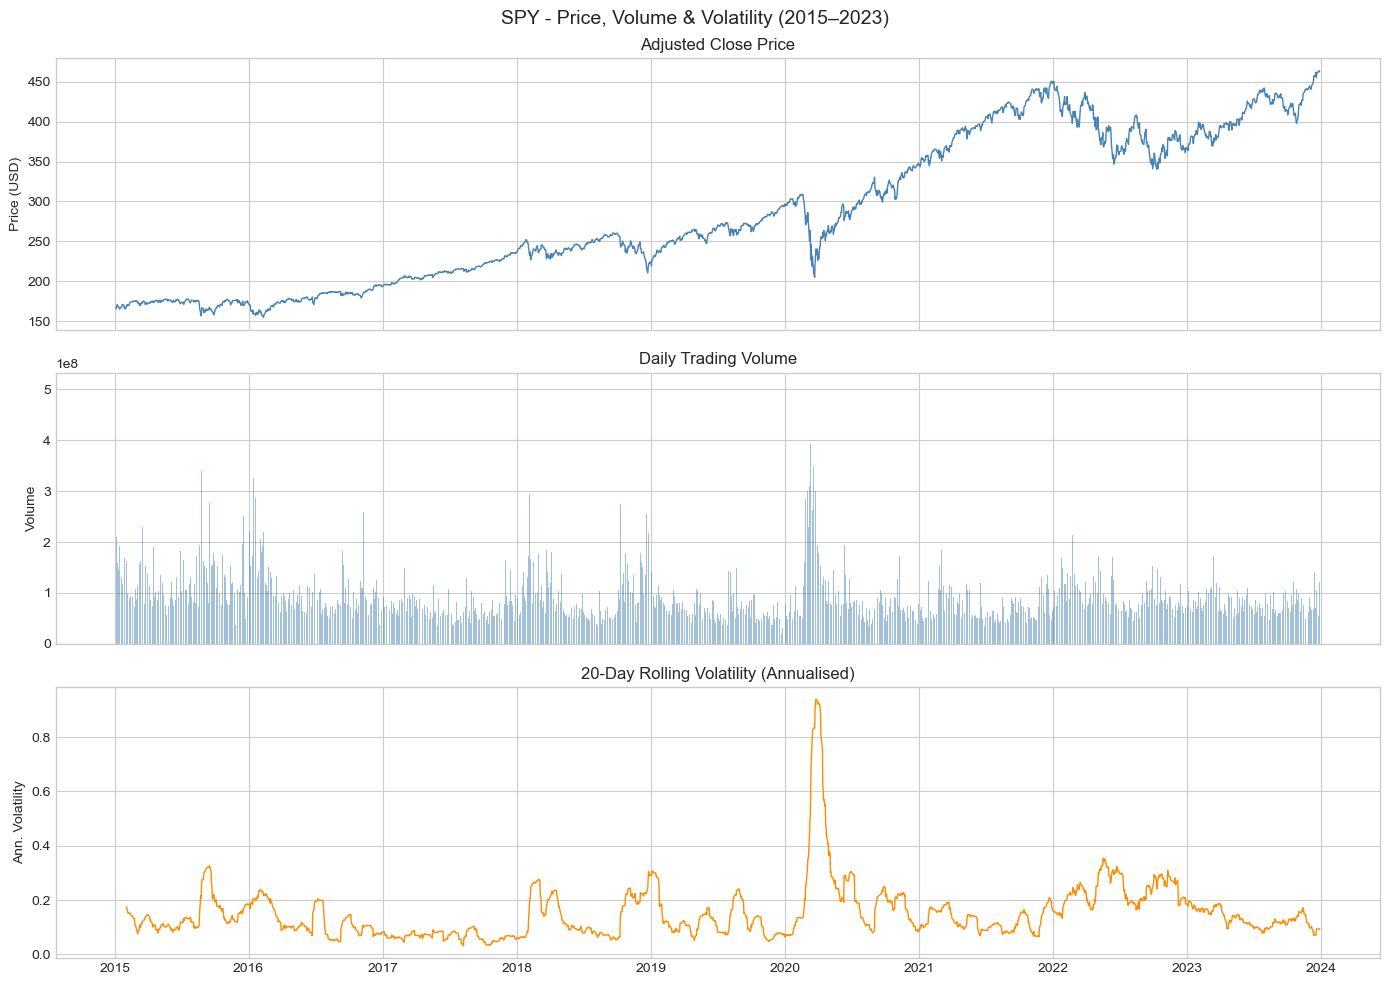

Figure 1 saved.


In [5]:
# Figure 1: Price history and volume
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f'{TICKER} - Price, Volume & Volatility ({START[:4]}–{END[:4]})', fontsize=14)

# Close price
axes[0].plot(df.index, df['Close'], color='steelblue', linewidth=1)
axes[0].set_ylabel('Price (USD)')
axes[0].set_title('Adjusted Close Price')

# Volume
axes[1].bar(df.index, df['Volume'], color='steelblue', alpha=0.5, width=1)
axes[1].set_ylabel('Volume')
axes[1].set_title('Daily Trading Volume')

# 20-day rolling volatility
axes[2].plot(df.index, df['vol_20d'], color='darkorange', linewidth=1)
axes[2].set_ylabel('Ann. Volatility')
axes[2].set_title('20-Day Rolling Volatility (Annualised)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_price_volume_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

Interpretation:
- Price growth along the years, COVID crash in Mar 2020 and recovery.
- relationship of volume with closing prices 

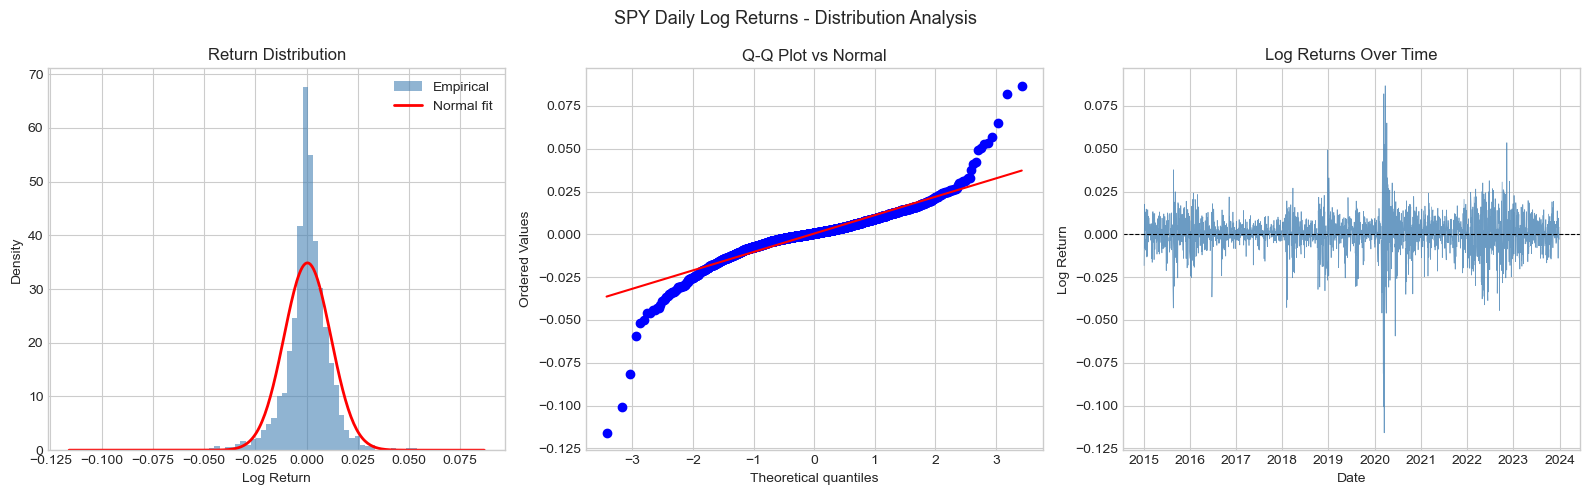

=== Returns Summary ===
Mean daily return  : 0.000442
Std dev            : 0.011439
Skewness           : -0.7945  (negative = left tail heavier)
Excess Kurtosis    : 13.5102  (>0 = fat tails vs Normal)
Min                : -0.1159
Max                : 0.0867


In [6]:
# Figure 2: Returns distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'{TICKER} Daily Log Returns - Distribution Analysis', fontsize=13)

returns = df['log_return'].dropna()

# Histogram + KDE vs Normal
axes[0].hist(returns, bins=80, density=True, color='steelblue', alpha=0.6, label='Empirical')
x = np.linspace(returns.min(), returns.max(), 300)
axes[0].plot(x, stats.norm.pdf(x, returns.mean(), returns.std()), 'r-', lw=2, label='Normal fit')
axes[0].set_title('Return Distribution')
axes[0].set_xlabel('Log Return')
axes[0].set_ylabel('Density')
axes[0].legend()

# Q-Q plot (test normality visually)
stats.probplot(returns, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot vs Normal')

# Time series of returns (fat tails visible)
axes[2].plot(df.index, returns, color='steelblue', linewidth=0.5, alpha=0.8)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Log Returns Over Time')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Log Return')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print('=== Returns Summary ===')
print(f'Mean daily return  : {returns.mean():.6f}')
print(f'Std dev            : {returns.std():.6f}')
print(f'Skewness           : {returns.skew():.4f}  (negative = left tail heavier)')
print(f'Excess Kurtosis    : {returns.kurtosis():.4f}  (>0 = fat tails vs Normal)')
print(f'Min                : {returns.min():.4f}')
print(f'Max                : {returns.max():.4f}')

interpretation:
- Return Distribution: not normally distributed. The red curve (perfect normal) doesnt match blue bars. meaning large moves (both crashes and rallies) occur far more frequently than a normal distribution would predict.
- Q-Q plot vs normal: Points far from the diagonal line = non-normal. The extremes curve away, confirming the interpretation for return distribution.
- Log returns: interesting volatility clustering, as discussed in lectures, big moves follow big moves, calm periods follow calm periods (trends).

These points makes up the using of Random Forest over linear models

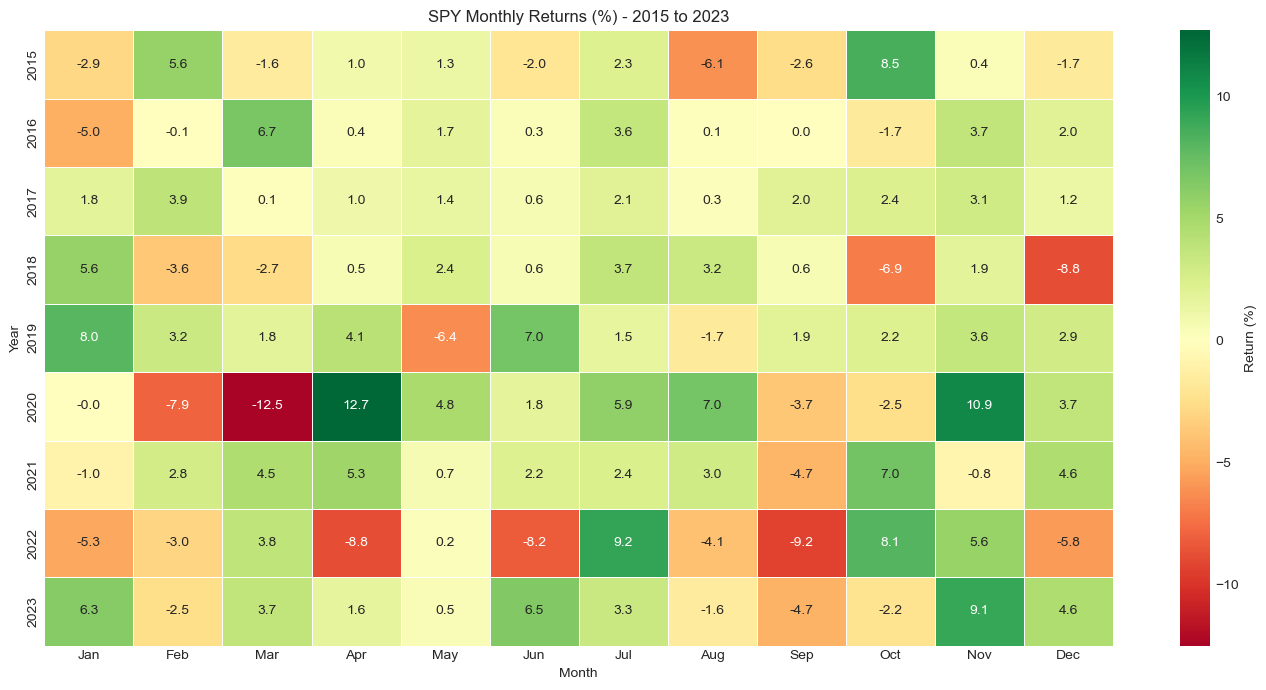

Figure 3 saved.


In [7]:
# Figure 3: Annual returns heatmap
df['year']  = df.index.year
df['month'] = df.index.month

monthly_returns = df.groupby(['year', 'month'])['simple_return'].apply(
    lambda x: (1 + x).prod() - 1
).unstack()

monthly_returns.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                            'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    monthly_returns * 100,
    annot=True, fmt='.1f', cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Return (%)'}
)
ax.set_title(f'{TICKER} Monthly Returns (%) - {START[:4]} to {END[:4]}')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_monthly_returns_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## 4. Stationarity Testing - Augmented Dickey-Fuller (ADF)

Since Raw price levels are non-stationary (they trend), we use **log returns** instead (as mentioned in lecture). 

We need to verify this before using them as model features - use ADF.

### What this test does
- The ADF test checks for a **unit root**.
- **H0 (null):** series has a unit root -> non-stationary.
- **H1 (alternative):** series is stationary.
- Decision rule: if `p-value < 0.05`, reject H0.

### running it on both raw prices and log returns
- **Raw prices (`close`)** usually trend over time, so ADF often fails to reject H0 -> non-stationary.
- **Log returns (`log_return`)** remove trend and scale effects, so ADF is more likely to reject H0 -> stationary.

### Interpretation for this project
- If raw prices are non-stationary and log returns are stationary, we should use **log returns (and derived features)** for ML modeling, not raw price levels.

In [8]:
def run_adf_test(series, series_name, significance=0.05):
    """
    Run Augmented Dickey-Fuller test and print a formatted summary.
    Returns the ADF result tuple.
    """
    clean = series.dropna()
    result = adfuller(clean, autolag='AIC')  # AIC selects optimal lag automatically
    
    adf_stat  = result[0]
    p_value   = result[1]
    used_lags = result[2]
    n_obs     = result[3]
    crit_vals = result[4]
    
    stationary = p_value < significance
    status = '✓ STATIONARY' if stationary else '✗ NON-STATIONARY'
    
    print(f'\n--- ADF Test: {series_name} ---')
    print(f'ADF Statistic : {adf_stat:.4f}')
    print(f'p-value       : {p_value:.6f}   →  {status}')
    print(f'Lags used     : {used_lags}  |  Obs: {n_obs}')
    print('Critical values:')
    for key, val in crit_vals.items():
        print(f'  {key}: {val:.4f}')
    
    return result

# Test raw close price (expected NON-stationary)
adf_price = run_adf_test(df['Close'], 'SPY Close Price')

# Test log returns (expected STATIONARY)
adf_returns = run_adf_test(df['log_return'], 'SPY Log Returns')


--- ADF Test: SPY Close Price ---
ADF Statistic : -0.1931
p-value       : 0.939334   →  ✗ NON-STATIONARY
Lags used     : 10  |  Obs: 2252
Critical values:
  1%: -3.4333
  5%: -2.8628
  10%: -2.5675

--- ADF Test: SPY Log Returns ---
ADF Statistic : -14.8079
p-value       : 0.000000   →  ✓ STATIONARY
Lags used     : 9  |  Obs: 2253
Critical values:
  1%: -3.4333
  5%: -2.8628
  10%: -2.5675


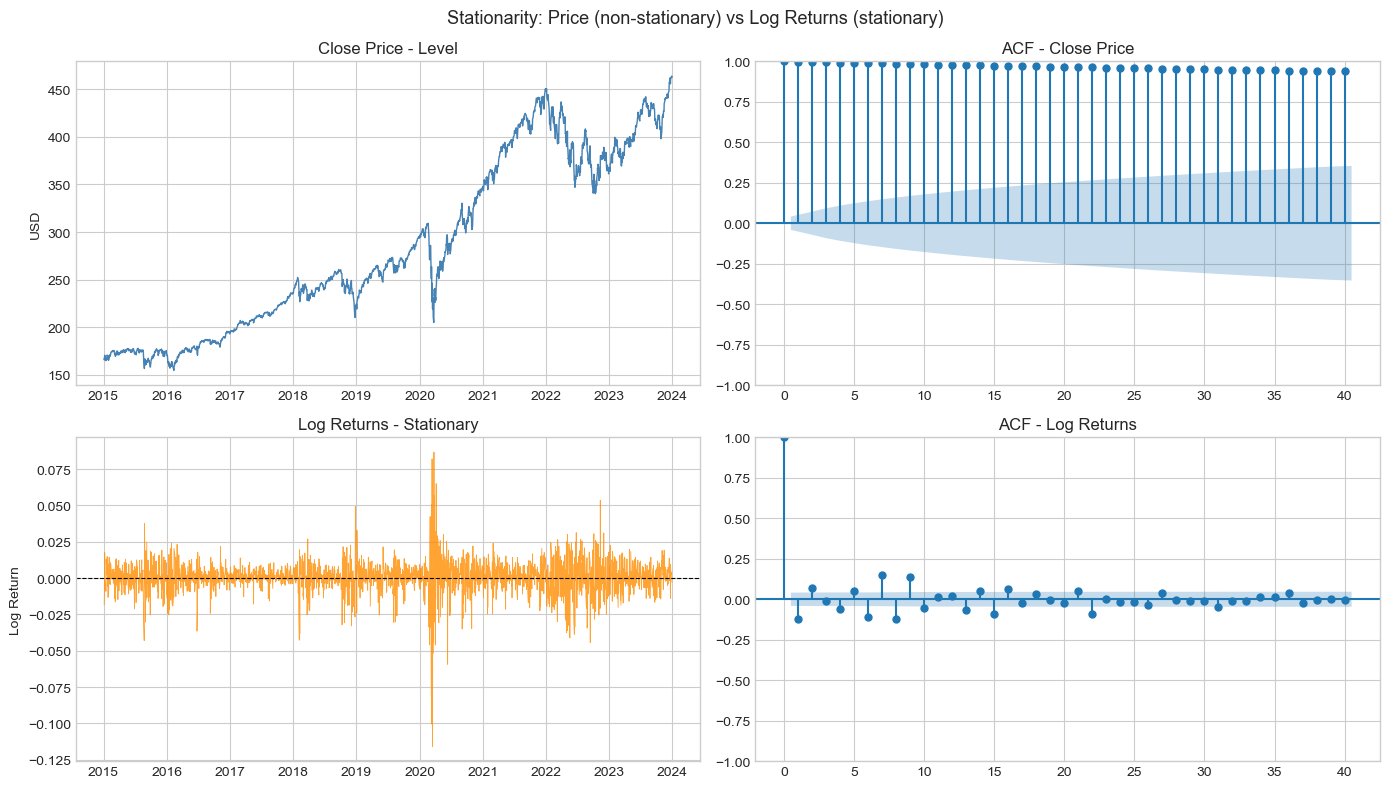

Figure 4 saved.


In [9]:
# Figure 4: Visualise stationarity - price vs returns
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Stationarity: Price (non-stationary) vs Log Returns (stationary)', fontsize=13)

# Price level
axes[0, 0].plot(df.index, df['Close'], color='steelblue', linewidth=1)
axes[0, 0].set_title('Close Price - Level')
axes[0, 0].set_ylabel('USD')

# Price ACF (shows persistent autocorrelation = non-stationary)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df['Close'].dropna(), lags=40, ax=axes[0, 1], title='ACF - Close Price')

# Log returns
axes[1, 0].plot(df.index, df['log_return'], color='darkorange', linewidth=0.6, alpha=0.8)
axes[1, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1, 0].set_title('Log Returns - Stationary')
axes[1, 0].set_ylabel('Log Return')

# Returns ACF (should decay quickly = stationary)
plot_acf(df['log_return'].dropna(), lags=40, ax=axes[1, 1], title='ACF - Log Returns')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_stationarity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

interpretation:
- Top-left (Price): Clearly trends upward - non-stationary.
- Top-right (Price ACF): Autocorrelation stays HIGH for many lags (bars remain tall)- non-stationary.
- Bottom-left (Log Returns): Bounces around zero with no trend - stationary.
- Bottom-right (Returns ACF): Autocorrelation drops OFF quickly -stationary .

## 5. Dynamic Time Warping (DTW)

**Why DTW instead of Pearson correlation?**  
Pearson correlation assumes linear relationships and is sensitive to time alignment vs DTW measures similarity between time series that may be shifted or stretched in time, making it more robust for financial data.

Using DTW to compare SPY's rolling returns across different market regimes (Pre-COVID, COVID crash, Post-COVID recovery), which will inform our train/test split strategy.

**Market regimes split (based on intuition):** 
1. **2015–2016:** Post-Krauss bull - refers to the bull-market phase after the period seen in benchmark paper (Krauss et al.).
2. **2017–2018:** Volatile consolidation (choppy, sideways)
3. **2019:** Pre-COVID rally (calm climb)
4. **2020–2021:** COVID crash & recovery (extreme volatility)
5. **2022–2023:** Rate-hike bear (falling as interest rates rose)

In [10]:
# Define market regime periods for DTW comparison

regimes = {
    'Post-Krauss bull run (2015–2016)' : ('2015-01-01', '2016-12-31'),
    'Volatile consolidation (2017–2018)': ('2017-01-01', '2018-12-31'),
    'Pre-COVID rally (2019)'            : ('2019-01-01', '2019-12-31'),
    'COVID crash & recovery (2020–2021)': ('2020-01-01', '2021-12-31'),
    'Rate-hike bear (2022–2023)'        : ('2022-01-01', '2023-12-31'),
}

# Extract log returns for each regime
regime_returns = {}
for name, (s, e) in regimes.items():
    subset = df.loc[s:e, 'log_return'].dropna().values.astype(np.float64)
    regime_returns[name] = subset
    print(f'{name}: {len(subset)} trading days')

Post-Krauss bull run (2015–2016): 503 trading days
Volatile consolidation (2017–2018): 502 trading days
Pre-COVID rally (2019): 252 trading days
COVID crash & recovery (2020–2021): 505 trading days
Rate-hike bear (2022–2023): 501 trading days


In [11]:
# Compute pairwise DTW distance matrix across regimes
# We normalise each series to unit length so DTW distances are comparable despite different regime durations.

def normalise_series(s):
    """Z-score normalise a 1D numpy array."""
    return (s - s.mean()) / (s.std() + 1e-8)

regime_names = list(regime_returns.keys())
n = len(regime_names)
dtw_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        s1 = normalise_series(regime_returns[regime_names[i]])
        s2 = normalise_series(regime_returns[regime_names[j]])
        # Use fast DTW with a Sakoe-Chiba band constraint (window=10%)
        window = max(1, int(min(len(s1), len(s2)) * 0.10))
        dist = dtw.distance_fast(s1, s2, window=window)
        dtw_matrix[i, j] = dist
        dtw_matrix[j, i] = dist

dtw_df = pd.DataFrame(dtw_matrix, index=regime_names, columns=regime_names)
print('DTW Distance Matrix (lower = more similar regimes):')
print(dtw_df.round(2))

DTW Distance Matrix (lower = more similar regimes):
                                    Post-Krauss bull run (2015–2016)  \
Post-Krauss bull run (2015–2016)                              0.0000   
Volatile consolidation (2017–2018)                           18.4000   
Pre-COVID rally (2019)                                       16.0400   
COVID crash & recovery (2020–2021)                           20.6300   
Rate-hike bear (2022–2023)                                   16.9400   

                                    Volatile consolidation (2017–2018)  \
Post-Krauss bull run (2015–2016)                               18.4000   
Volatile consolidation (2017–2018)                              0.0000   
Pre-COVID rally (2019)                                         16.6400   
COVID crash & recovery (2020–2021)                             22.6100   
Rate-hike bear (2022–2023)                                     20.0600   

                                    Pre-COVID rally (2019)  \
Post-Kra

**Normalisation step:** Before comparing regimes with DTW, we Z-score normalise each series.

process: subtract mean, divide by std dev. 

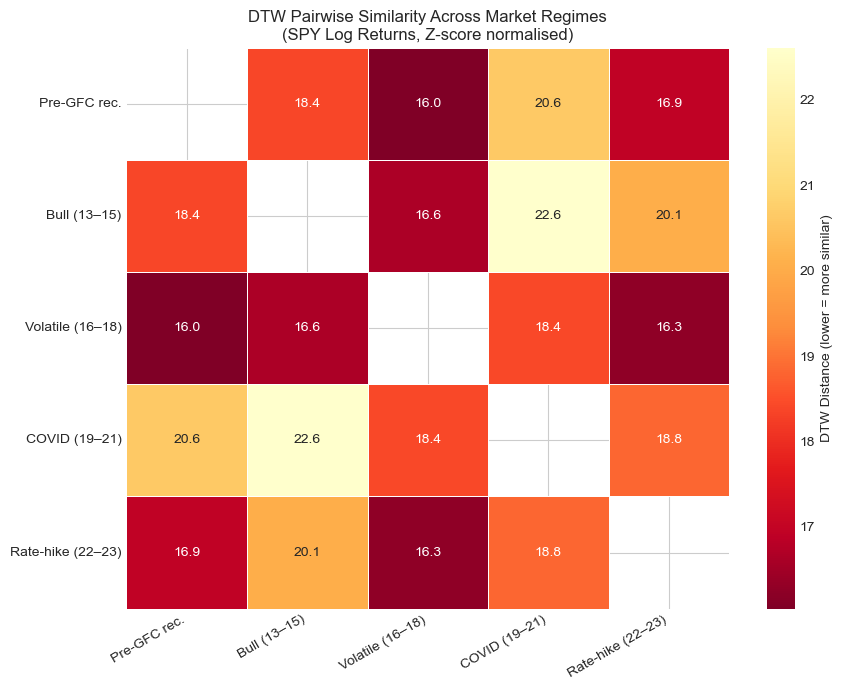

Figure 5 saved.


In [12]:
# Figure 5: DTW heatmap
short_labels = [
    'Pre-GFC rec.', 'Bull (13–15)', 'Volatile (16–18)',
    'COVID (19–21)', 'Rate-hike (22–23)'
]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.eye(n, dtype=bool)  # Mask diagonal
sns.heatmap(
    dtw_df,
    annot=True, fmt='.1f', cmap='YlOrRd_r',
    xticklabels=short_labels, yticklabels=short_labels,
    mask=mask, linewidths=0.5, ax=ax,
    cbar_kws={'label': 'DTW Distance (lower = more similar)'}
)
ax.set_title('DTW Pairwise Similarity Across Market Regimes\n(SPY Log Returns, Z-score normalised)')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_dtw_regime_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

In [13]:
# DTW Interpretation
print('=== DTW Interpretation ===')
print()
print('Lower DTW distance → more similar return patterns between regimes.')
print('This informs our train/test split strategy:')
print()

# Find most and least similar pair
upper_tri = [(i, j) for i in range(n) for j in range(i+1, n)]
most_similar  = min(upper_tri, key=lambda x: dtw_matrix[x[0], x[1]])
least_similar = max(upper_tri, key=lambda x: dtw_matrix[x[0], x[1]])

print(f'Most similar regimes  : "{regime_names[most_similar[0]]}" & "{regime_names[most_similar[1]]}"')
print(f'  DTW distance        : {dtw_matrix[most_similar[0], most_similar[1]]:.2f}')
print()
print(f'Least similar regimes : "{regime_names[least_similar[0]]}" & "{regime_names[least_similar[1]]}"')
print(f'  DTW distance        : {dtw_matrix[least_similar[0], least_similar[1]]:.2f}')
print()
print('Implication: Walk-forward validation is essential — the RF model trained on')
print('one regime may not generalise to structurally different regimes.')

=== DTW Interpretation ===

Lower DTW distance → more similar return patterns between regimes.
This informs our train/test split strategy:

Most similar regimes  : "Post-Krauss bull run (2015–2016)" & "Pre-COVID rally (2019)"
  DTW distance        : 16.04

Least similar regimes : "Volatile consolidation (2017–2018)" & "COVID crash & recovery (2020–2021)"
  DTW distance        : 22.61

Implication: Walk-forward validation is essential — the RF model trained on
one regime may not generalise to structurally different regimes.


Interpretation: Since different regimes show very different return patterns, a model trained on one regime (e.g., bull market) may fail when applied to another (e.g., bear market). This is why **walk-forward validation** is critical—we train on old data and test on newer, structurally different data to simulate real-world conditions.

## 6. Train / Test Split Design

**walk-forward** split no random shuffling. 

| Split | Period | Purpose |
|-------|--------|---------|
| Training (in-sample) | 2015–2020 | Model fitting + hyperparameter tuning |
| Test (out-of-sample) | 2021–2023 | Final evaluation |

In [14]:
# Define splits and save clean dataset
TRAIN_END  = '2020-12-31'
TEST_START = '2021-01-01'

df_train = df.loc[:TRAIN_END].copy()
df_test  = df.loc[TEST_START:].copy()

print(f'Training set : {df_train.index[0].date()} → {df_train.index[-1].date()}  ({len(df_train)} days)')
print(f'Test set     : {df_test.index[0].date()} → {df_test.index[-1].date()}  ({len(df_test)} days)')
print(f'\nTrain/Test split: {len(df_train)/(len(df_train)+len(df_test)):.1%} / {len(df_test)/(len(df_train)+len(df_test)):.1%}')

# Save clean OHLCV + returns dataset for use in Phase 2
df.to_csv(DATA_DIR / 'SPY_clean_data.csv')
print('\nClean dataset saved to data/SPY_clean_data.csv — ready for Phase 2 (Feature Engineering).')

Training set : 2015-01-05 → 2020-12-31  (1510 days)
Test set     : 2021-01-04 → 2023-12-29  (753 days)

Train/Test split: 66.7% / 33.3%

Clean dataset saved to data/SPY_clean_data.csv — ready for Phase 2 (Feature Engineering).


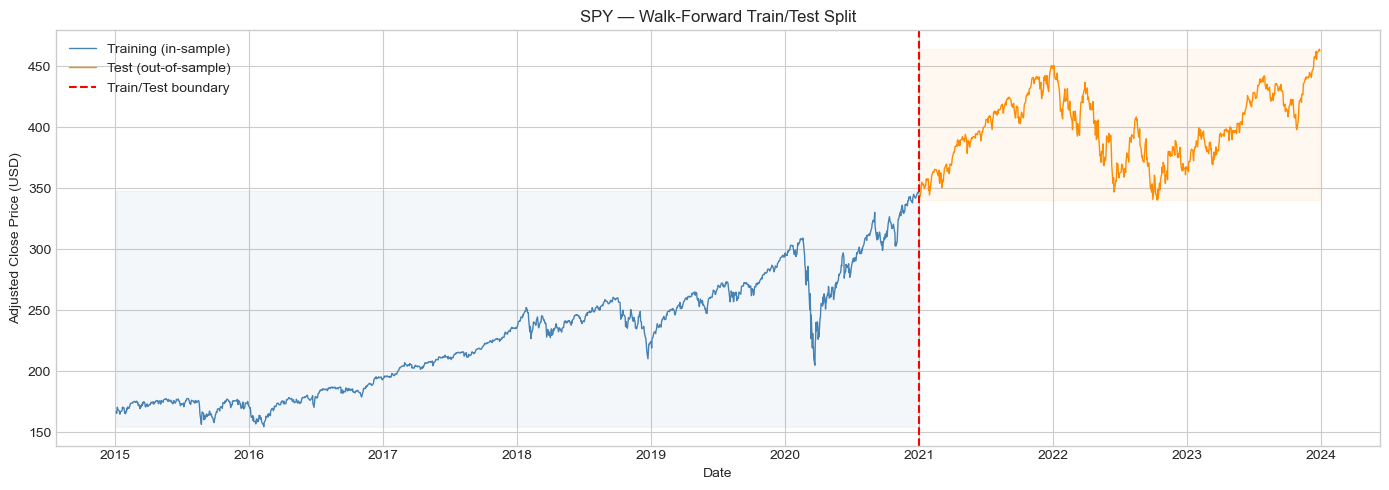

Figure 6 saved.


In [15]:
# Figure 6: Train/test split visualisation
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_train.index, df_train['Close'], color='steelblue', linewidth=1, label='Training (in-sample)')
ax.plot(df_test.index,  df_test['Close'],  color='darkorange', linewidth=1, label='Test (out-of-sample)')
ax.axvline(pd.Timestamp(TEST_START), color='red', linestyle='--', linewidth=1.5, label='Train/Test boundary')

ax.fill_between(df_train.index, df_train['Close'].min(), df_train['Close'].max(),
                alpha=0.06, color='steelblue')
ax.fill_between(df_test.index, df_test['Close'].min(), df_test['Close'].max(),
                alpha=0.06, color='darkorange')

ax.set_title(f'{TICKER} — Walk-Forward Train/Test Split')
ax.set_xlabel('Date')
ax.set_ylabel('Adjusted Close Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

---
## 7. Phase 1 Summary

| Item | Finding |
|------|--------|
| Instrument | SPY (S&P 500 ETF) |
| Period | 2015–2023 |
| Missing values | 0 |
| Price stationarity (ADF) | Non-stationary (as expected) |
| Returns stationarity (ADF) | Stationary - confirmed, safe for ML features |
| Return distribution | Negative skew, excess kurtosis (fat tails) - consistent with financial literature |
| DTW similarity | COVID (2019–2021) and Rate-hike (2022–2023) regimes are most dissimilar - supports walk-forward approach |
| Train/Test split | 2015–2020 (train) / 2021–2023 (test) - no shuffle, temporal order preserved |


**Next:** Phase 2 feature engineering (technical indicators, lag features, target variable creation) that the Random Forest will use for trading signal prediction.